In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import warpSPHCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import warpSPHCore as sph
from warpSPHCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from warpSPHIntegrators.integration import *
from warpSPHCore import *
from warpSPHPlotting import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.16.0


In [2]:
L = 2
nx = 17
# for periodic
dx = L / nx
dim = 2

xx = torch.linspace(-L/2 + dx/2, L/2 - dx/2, nx)
print(xx[1] - xx[0] - dx)
yy = torch.linspace(-L/2 + dx/2, L/2 - dx/2, nx)

n_h = 4
targetNeighbors = n_h_to_nH(n_h, 2)
print(f"targetNeighbors: {targetNeighbors}")

h = volumeToSupport(dx**dim, targetNeighbors, dim)
print(h)

tensor(-7.4506e-09)
targetNeighbors: 50.26548245743669
0.4705882352941177


num_per_axis: 17, half_sample: 8
tensor(-7.4506e-09) tensor(0.)


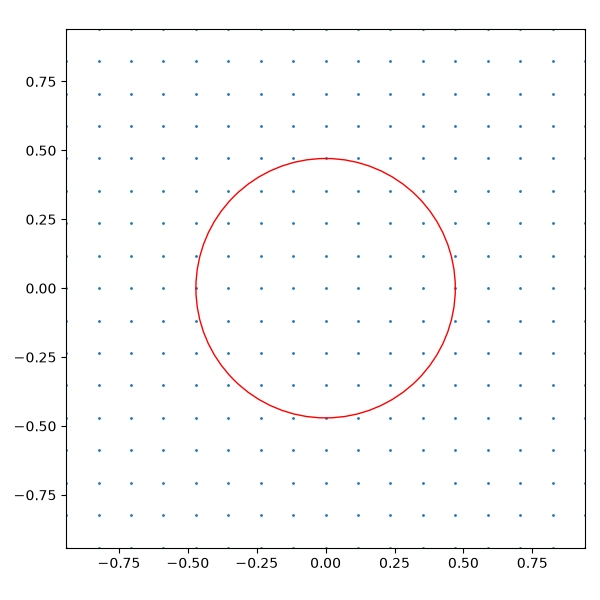

In [3]:
# We now sample from -2h to 2h oriented on the center
num_per_axis = int(4 * h / dx)
# if even make odd
num_per_axis += 1 - num_per_axis % 2
half_sample = (num_per_axis - 1) // 2
print(f"num_per_axis: {num_per_axis}, half_sample: {half_sample}")
dtype = get_torch_precision()

xx_h = torch.linspace(-half_sample * dx, half_sample * dx, num_per_axis, dtype = dtype)
print(xx_h[1] - xx_h[0] - dx, xx_h[len(xx_h)//2])
yy_h = torch.linspace(-half_sample * dx, half_sample * dx, num_per_axis, dtype = dtype)

grid = torch.meshgrid(xx_h, yy_h, indexing='ij')
positions = torch.stack(grid, dim=-1).reshape(-1, 2)

fig, axis = plt.subplots(1, 1, figsize=(6, 6), squeeze=False)
axis[0, 0].scatter(positions[:, 0], positions[:, 1], s=1)

circ = plt.Circle((0, 0), h, color='r', fill=False)
axis[0, 0].add_artist(circ)

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(-2 * h, 2 * h)
    ax.set_ylim(-2 * h, 2 * h)
fig.tight_layout()

In [4]:
h = volumeToSupport(dx**dim, targetNeighbors, dim)

particles = ParticleState(
    positions = positions,
    supports = torch.full((positions.shape[0],), h, dtype=dtype),
    masses = torch.full((positions.shape[0],), dx**dim, dtype=dtype),
    densities= torch.full((positions.shape[0],), 1.0, dtype=dtype),
    kinds=torch.full((positions.shape[0],), 0, dtype=torch.int32)
)

centralParticle = ParticleState(
    positions = torch.zeros((1, 2), dtype=dtype),
    supports = torch.full((1,), h, dtype=dtype),
    masses = torch.full((1,), dx**dim, dtype=dtype),
    densities= torch.full((1,), 1.0, dtype=dtype),
    kinds = torch.full((1,), 0, dtype=torch.int32)
)

centralParticle.supports[0] = h
particles.supports[:] = h

domain = buildDomainDescription(
    l = 4 * h,
    dim = 2,
    periodic=False,
    dtype = get_torch_precision()
)

density = warpOperation(
    queryParticles=centralParticle,
    referenceParticles=particles,
    operationProperties=OperationProperties(
        operation = WarpOperation.Density,
        kernel = KernelFunctions.Wendland2
    ),
    domain = domain
)

print(f"Density: {density[0]}")
# This value indicates the error of h for this specific chosen lattice
# We can then run a newton iteration to find the h that gives us the target density. This is a simple 1D root finding problem.


Module warpSPHCore.radiusSearch.compactHash.wp_index 5cfdc6a load on device 'cpu' took 0.71 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_hashCells 476309e load on device 'cpu' took 0.11 ms  (cached)
Module warpSPHCore.coreOperations.wp_density 9ca6aec load on device 'cpu' took 0.13 ms  (cached)
Density: 1.0012056827545166


In [5]:
# What this means in effect is that the sph kernel assumes that the integral of the kernel is 1 with its c_d factor
# however, for a specific discretization it will not sum to 1
# This is the density offset we measure here and is based on:
# 1: the specific kernel
# 2: the target number of neighbors
# 3: the dimensionality
# but not the target resolution, it does not converge with dx -> 0 but with h -> infty
# more specifically, it would converge with dx -> 0 and h = const (increasing the number of neighbors for each particle)
# ideally we want to be able to compute this error for any kernel and any number of neighbors, so we can correct for it in the kernel constant

In [8]:
kernel = kernelState()
kernel.kernelFunction=KernelFunctions.Wendland2.value
kernel.supportMode = wp.uint32(SupportScheme.Gather.value)

kernel.gradientMode = 0
kernel.laplacianMode = 0
kernel.positiveDivergenceMode = False
kernel.divergenceMode = False
kernel.operationMode = 0

from warpSPHCore.kernels import eval_k, eval_C_d
n_h = 4
targetNeighbors = n_h_to_nH(n_h, dim)
h = volumeToSupport(dx**dim, targetNeighbors, dim)
kernelSum = 0.0

for ix in np.arange(-n_h, n_h + 1):
    for iy in np.arange(-n_h, n_h + 1):
        pos = wp.vec2f(ix * dx, iy * dx)
        h_tensor = wp.float32(h)
        q = wp.length(pos) / h_tensor
        W_ij = eval_k(q, dim, kernel.kernelFunction) 
        kernelSum += W_ij

# h = volumeToSupport(dx**dim, targetNeighbors, dim)
# for 2d:
# math.sqrt(targetNeighbors * volume / np.pi)
h = math.sqrt(targetNeighbors / np.pi) * dx
h_pow = h**dim
sum = kernelSum * dx ** dim * eval_C_d(dim, kernel.kernelFunction) / h_pow
# becuase we have dx ** dim and divide by h**dim which contains dx directly these terms do infact cancel out
h_factor = math.sqrt(targetNeighbors / np.pi) ** dim
sum = kernelSum * eval_C_d(dim, kernel.kernelFunction) / h_factor
# because dim == 2 we further get
sum = kernelSum * eval_C_d(dim, kernel.kernelFunction) * np.pi / targetNeighbors
# with n_h_to_nH(n_h, dim) we can also write this as
# targetNeighbors = n_h_to_nH(n_h, 2):
    # spacing = 1.0 / n_h
    # v = spacing ** dim
    # vH = 2.0 if dim == 1 else (np.pi if dim == 2 else (4.0 / 3.0) * np.pi)
    # return vH / v

spacing = 1.0 / n_h
v = spacing ** 2
vH = np.pi
targetNeighbors = vH / v

sum = kernelSum * eval_C_d(dim, kernel.kernelFunction) * np.pi / targetNeighbors
# the np.pi now cancels out with vH
# we then divide by v internally and then divide by this term again so we can also write
sum = kernelSum * eval_C_d(dim, kernel.kernelFunction) * v
# or more directly
sum = kernelSum * eval_C_d(dim, kernel.kernelFunction) / n_h**2

error = sum - 1.0

# what we now want to compute is a factor such that the error is 0
# i.e., sum * factor = 1.0
factor = 1.0 / sum
# or more directly we can write this as
factor = 1.0 / kernelSum / eval_C_d(dim, kernel.kernelFunction) * n_h**2
print(f'Factor: {factor}, error: {error}, sum: {sum}, error vs density: {density[0] - sum}')



print(f"Sum of kernel contributions: {sum}, error: {1.0 - sum} [error vs density: {density[0] - sum}]")

Factor: 0.9987956890292331, error: 0.001205763084477729, sum: 1.0012057630844777, error vs density: -1.1920928955078125e-07
Sum of kernel contributions: 1.0012057630844777, error: -0.001205763084477729 [error vs density: -1.1920928955078125e-07]


## Closed form for the lattice density offset

On a perfect cubic lattice of spacing $dx$ with $h = n_h\,dx$, the SPH density at a lattice site is

$$S(n_h)\;=\;\frac{\rho}{\rho_0}\;=\;\frac{C_d}{n_h^{d}}\sum_{\mathbf n\in\mathbb Z^{d}} k\!\left(\frac{|\mathbf n|}{n_h}\right)\;\neq\;1 .$$

(The $dx^{d}$ from the mass and the $h^{-d}$ from the kernel cancel exactly, which is why the offset never depends on the resolution.) Three ways to evaluate it, each closer to a closed form:

**1 — collapse the $d$-fold integer loop to one sum.** $|\mathbf n|^2=j$ is an integer, so with $r_d(j)=\#\{\mathbf n\in\mathbb Z^d:|\mathbf n|^2=j\}$

$$S(n_h)=\frac{C_d}{n_h^{d}}\sum_{j=0}^{\lfloor n_h^2\rfloor} r_d(j)\,k\!\left(\frac{\sqrt j}{n_h}\right),\qquad
r_2(j)=4\!\!\sum_{\substack{e\mid j\\ e\ \mathrm{odd}}}\!\!(-1)^{(e-1)/2}$$

the last being Jacobi's two-square theorem — a genuine closed form for the multiplicity. Exact, and $O(n_h^2)$ terms instead of $O(n_h^d)$.

**2 — Poisson summation: the offset *is* the kernel's Fourier transform on the reciprocal lattice.** With $\hat w(s)$ the $d$-dimensional radial FT of the normalised kernel $W(r)=C_d h^{-d}k(r/h)$ at $|\boldsymbol\xi|h=s$ (so $\hat w(0)=1$):

$$\boxed{\;S(n_h)\;=\;\sum_{\mathbf m\in\mathbb Z^{d}}\hat w\!\left(2\pi n_h|\mathbf m|\right)\;=\;1+\sum_{j\ge 1} r_d(j)\,\hat w\!\left(2\pi n_h\sqrt j\right)\;}$$

$$\hat w(s)=\frac{(2\pi)^{d/2}C_d}{s^{d/2-1}}\int_0^1 k(q)\,q^{d/2}J_{d/2-1}(sq)\,dq
=\begin{cases}
2C_1\displaystyle\int_0^1 k\cos(sq)\,dq & d=1\\[4pt]
2\pi C_2\displaystyle\int_0^1 k\,q\,J_0(sq)\,dq & d=2\\[4pt]
\dfrac{4\pi C_3}{s}\displaystyle\int_0^1 k\,q\sin(sq)\,dq & d=3
\end{cases}$$

Elementary in 1D and 3D (polynomial × cos/sin); in 2D it is a finite combination of $J_0(s)$, $J_1(s)$ and $\int_0^1\!J_0(sq)dq$ (Struve). E.g. Wendland-2 in 2D, exactly:

$$\hat w(s)=14\left[\frac{900\,J_0(s)}{s^{6}}-\frac{60\,J_1(s)}{s^{5}}+\frac{180(s^{2}-5)}{s^{6}}\,\mathrm I_0(s)\right],\qquad \mathrm I_0(s)=\int_0^1\!\! J_0(sq)\,dq .$$

No integers survive in the argument, so this holds for **any real $n_h$**, and it makes the structure obvious: the offset is aliasing, it depends only on $(k,d,n_h)$, and it dies as $n_h\to\infty$ at the rate of the kernel's spectral decay.

**3 — fully sum-free.** The non-oscillatory tail of $\hat w$ comes only from the **odd** powers in the Taylor expansion $k(q)=\sum_m c_m q^m$ at $q=0$ (even powers are polynomials in $\mathbf x$ and have no algebraic tail):

$$\hat w(s)\;\sim\;\sum_{m\ \mathrm{odd}} c_m C_d\,\Lambda_d(m)\,s^{-(d+m)},\qquad
\Lambda_d(m)=(2\pi)^{d/2}\,2^{\,m+d/2}\,\frac{\Gamma\!\left(\frac{d+m}{2}\right)}{\Gamma\!\left(-\frac m2\right)} .$$

Substituting into the shell sum, every $\sum_j r_d(j)\,j^{-\sigma}$ is the **Epstein zeta function** of $\mathbb Z^d$ — a constant:

$$\boxed{\;S(n_h)\;\simeq\;1+\sum_{m\ \mathrm{odd}} \frac{A_m\,Z_d\!\left(\frac{d+m}{2}\right)}{(2\pi n_h)^{d+m}},\qquad A_m=c_m C_d\Lambda_d(m),\qquad
\text{factor}=\frac1{S(n_h)}\;}$$

with $Z_1(\sigma)=2\zeta(2\sigma)$, $Z_2(\sigma)=4\zeta(\sigma)\beta(\sigma)$ ($\beta$ = Dirichlet beta), $Z_3$ a tabulated constant. The $A_m$ are integers, e.g. Wendland-2 in 2D: $A_3=2520$, $A_5=-12600$, so

$$S(n_h)\;\simeq\;1+\frac{2520\,Z_2(5/2)}{(2\pi n_h)^{5}}-\frac{12600\,Z_2(7/2)}{(2\pi n_h)^{7}},\qquad Z_2(5/2)=5.09026\ldots$$

**Caveats.** (i) The residual is the *oscillatory* part of $\hat w$, one half-power below the term kept — for Wendland this recovers ≳95 % of the offset at $n_h=4$ and improves fast with $n_h$. (ii) For B-splines the interior knots produce an oscillatory term that decays **slower** than the algebraic tail, so their offset changes sign with $n_h$ and has no smooth closed form — use route 1 or 2 there. (iii) Wendland kernels are positive definite, so $\hat w(s)>0$ for all $s$ and therefore $S(n_h)>1$ *strictly*: no choice of $h$ can make a lattice read $\rho_0$ — only the $C_d$ rescale works. (The Newton-on-$h$ / bisection idea above has no root for Wendland.)

In [7]:
# Closed-form lattice density offset -- see the markdown above for the derivation.
# This now lives in the library: warpSPHCore/util/latticeDensity.py, wired into
# scripts/lattice_density_offset.py and cases/weaklyCompressible's mass
# calibration. What is left here is the validation against the brute-force
# integer loop the cell above writes out by hand.
# NB: the cell above binds `sum` to a float, so nothing here uses the builtin sum().
import numpy as np
from warpSPHCore.util import (latticeDensity, latticeDensityFactor,
                              latticeDensityIsStrictlyAbove1,
                              shellCounts, jacobiR2)
from warpSPHCore.kernels.eval_kernel import eval_k, eval_C_d


def bruteForce(kernelFunction, n_h, dim):
    """The dim-fold integer loop, i.e. what cell 5 does, for reference."""
    N = int(np.ceil(n_h))
    G = np.meshgrid(*([np.arange(-N, N + 1)] * dim), indexing='ij')
    qs = np.sqrt(np.square(np.stack(G, 0).astype(float)).sum(0)).ravel() / n_h
    k = np.array([eval_k(float(q), dim, kernelFunction) if q <= 1.0 else 0.0 for q in qs])
    return float(eval_C_d(dim, kernelFunction) / n_h ** dim * k.sum())


# Jacobi's two-square theorem really is r_2(j).
assert np.array_equal(shellCounts(2, 2000), jacobiR2(2000))

print(f"{'kernel':14s} {'dim':>3s} {'n_h':>5s} {'brute loop':>16s} {'1 shells':>16s} "
      f"{'2 poisson':>16s} {'3 closed':>16s} {'factor 1/L':>13s}")
for kf in (KernelFunctions.CubicSpline, KernelFunctions.Wendland2,
           KernelFunctions.Wendland4, KernelFunctions.Wendland6):
    for d in (2, 3):
        for nh in (3.0, 3.7, 4.0, 5.0):          # 3.7 -- non-integer works too
            B = bruteForce(kf.value, nh, d)
            S = latticeDensity(kf, nh, d)                   # exact, one shell sum
            F = latticeDensity(kf, nh, d, 'fourier')        # exact, Poisson identity
            try:
                C = latticeDensity(kf, nh, d, 'closed')     # sum-free (Wendland only)
            except KeyError:
                C = float('nan')
            print(f'{kf.name:14s} {d:3d} {nh:5.2f} {B:16.12f} {S:16.12f} {F:16.12f} '
                  f'{C:16.12f} {latticeDensityFactor(kf, nh, d):13.10f}')

# Why cell 8's Newton/bisection on h cannot converge for a Wendland kernel:
# positive definite => what(s) > 0 for every s => every Poisson term is positive
# => L > 1 at every h. The splines are not, and do cross 1.
for kf in (KernelFunctions.Wendland2, KernelFunctions.Wendland4, KernelFunctions.CubicSpline):
    Ls = [latticeDensity(kf, r / 10, 2) for r in range(20, 81)]
    print(f'{kf.name:14s} strictlyAbove1={latticeDensityIsStrictlyAbove1(kf)!s:5s} '
          f'min L over n_h in [2, 8] = {min(Ls):.9f}')

kernel         dim   n_h       brute loop         1 shells        2 poisson         3 closed    factor 1/L
CubicSpline      2  3.00   1.003440249989   1.003440249989   1.003439961205              nan  0.9965715448
CubicSpline      2  3.70   1.000431016230   1.000431016230   1.000430512117              nan  0.9995691695
CubicSpline      2  4.00   0.999957545603   0.999957545603   0.999957331331              nan  1.0000424562
CubicSpline      2  5.00   1.000411948963   1.000411948963   1.000410753120              nan  0.9995882207
CubicSpline      3  3.00   1.001794561558   1.001794561558   1.001794704725              nan  0.9982086531
CubicSpline      3  3.70   1.000631555017   1.000631555017   1.000632286172              nan  0.9993688436
CubicSpline      3  4.00   1.000079065876   1.000079065876   1.000079369791              nan  0.9999209404
CubicSpline      3  5.00   1.000113109414   1.000113109414   1.000112432011              nan  0.9998869034
Wendland2        2  3.00   1.00514222

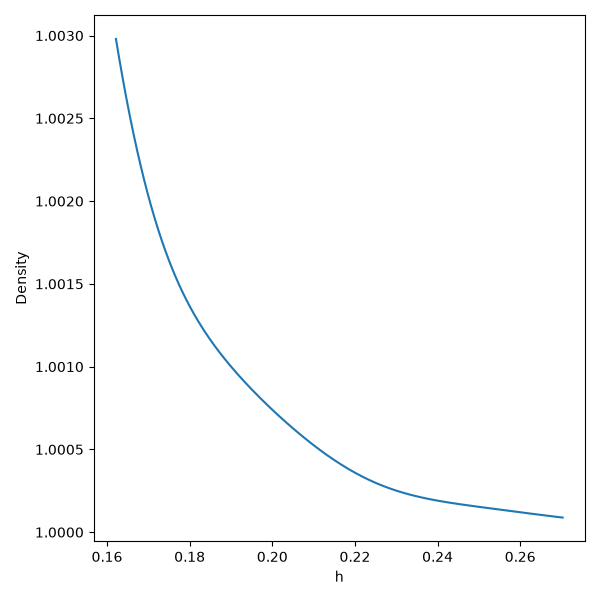

In [12]:
h_min = volumeToSupport(dx**dim, n_h_to_nH(3, dim), dim)
h_max = volumeToSupport(dx**dim, n_h_to_nH(5, dim), dim)

hs = torch.linspace(h_min, h_max, 255)

rhos = []
for h in hs:
    centralParticle.supports[0] = h
    particles.supports[:] = h
    density = warpOperation(
        queryParticles=centralParticle,
        referenceParticles=particles,
        operationProperties=OperationProperties(
            operation = WarpOperation.Density,
            kernel = KernelFunctions.Wendland4
        ),
        domain = domain
    )
    rhos.append(density[0].item())

fig, axis = plt.subplots(1, 1, figsize=(6, 6), squeeze=False)
axis[0, 0].plot(hs, rhos)
axis[0, 0].set_xlabel("h")
axis[0, 0].set_ylabel("Density")

fig.tight_layout()